- ####    Import the Libraries

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.figsize'] =(20,10)

- Import the dataset

In [70]:
df1=pd.read_csv('Bengaluru_House_Data.csv')
df1.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


- Number of rows and columns of the dataset

In [71]:
df1.shape

(13320, 9)

- number of datapoints in the dataset

In [72]:
df1.size

119880

- Column wise data information

In [73]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


- value counts for different Area type 

In [74]:
df1.groupby('area_type')['area_type'].agg('count')

area_type
Built-up  Area          2418
Carpet  Area              87
Plot  Area              2025
Super built-up  Area    8790
Name: area_type, dtype: int64

- Drop non related columns

In [75]:
df2=df1.drop(['area_type','balcony','availability','society'], axis='columns')
df2.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


- Check the null values

In [76]:
df2.isnull().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

- drop the missing values as they are very less

In [77]:
df3 = df2.dropna()
df3.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
price         0
dtype: int64

- check the rows and columns again

In [78]:
df3.shape

(13246, 5)

- Check the column 'size' to check the unique values

In [79]:
df3['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

- Create a 'bhk' column to keep the bhks from 'size' column

In [80]:
df3['bhk'] = df3['size'].apply(lambda x:int(x.split(" ")[0]) )

C:\Users\pc\AppData\Local\Temp\ipykernel_1680\1882302688.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['bhk'] = df3['size'].apply(lambda x:int(x.split(" ")[0]) )


In [81]:
df3.head()

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4
2,Uttarahalli,3 BHK,1440,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3
4,Kothanur,2 BHK,1200,2.0,51.00,2


In [82]:
df3.bhk.unique()

array([ 2,  4,  3,  6,  1,  8,  7,  5, 11,  9, 27, 10, 19, 16, 43, 14, 12,
       13, 18], dtype=int64)

In [83]:
df3[df3.bhk>20]

,location,size,total_sqft,bath,price,bhk
1718,2Electronic City Phase II,27 BHK,8000,27.0,230.0,27
4684,Munnekollal,43 Bedroom,2400,40.0,660.0,43


In [84]:
df3.total_sqft.unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

In [85]:
def is_float(x):
    try:
        float(x)
    except:
        return False
    return True

df3[~df3['total_sqft'].apply(is_float)].head(10)

,location,size,total_sqft,bath,price,bhk
30,Yelahanka,4 BHK,2100 - 2850,4.0,186.000,4
122,Hebbal,4 BHK,3067 - 8156,4.0,477.000,4
137,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,54.005,2
165,Sarjapur,2 BHK,1145 - 1340,2.0,43.490,2
188,KR Puram,2 BHK,1015 - 1540,2.0,56.800,2
410,Kengeri,1 BHK,34.46Sq. Meter,1.0,18.500,1
549,Hennur Road,2 BHK,1195 - 1440,2.0,63.770,2
648,Arekere,9 Bedroom,4125Perch,9.0,265.000,9
661,Yelahanka,2 BHK,1120 - 1145,2.0,48.130,2
672,Bettahalsoor,4 Bedroom,3090 - 5002,4.0,445.000,4


In [86]:
def convert_sqft_to_num(x):
    tokens = x.split('-')
    if len(tokens)==2:
        return(float(tokens[0])+float(tokens[1]))/2
    try:
        return float(x)
    except:
        return None

In [87]:
convert_sqft_to_num('2165')

2165.0

In [88]:
convert_sqft_to_num('34.46Sq. Meter')

In [89]:
df4 =df3.copy()

In [90]:
df4['total_sqft'] = df4['total_sqft'].apply(convert_sqft_to_num)

In [91]:
df4.loc[(30)]

location      Yelahanka
size              4 BHK
total_sqft       2475.0
bath                4.0
price             186.0
bhk                   4
Name: 30, dtype: object

In [92]:
df5 = df4.copy()
df5['price_per_sqft']=df5['price']*100000/df5['total_sqft']

In [93]:
df5.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000


In [94]:
df5.location.nunique()

1304

In [95]:
df5.location =df5.location.apply(lambda x:x.strip())
location_stats = df5.groupby('location')['location'].agg('count')

In [96]:
location_stats.sort_values(ascending=False)

location
Whitefield               535
Sarjapur  Road           392
Electronic City          304
Kanakpura Road           266
Thanisandra              236
                        ... 
1 Giri Nagar               1
Kanakapura Road,           1
Kanakapura main  Road      1
Karnataka Shabarimala      1
whitefiled                 1
Name: location, Length: 1293, dtype: int64

In [97]:
len(location_stats[location_stats<=10])

1052

In [98]:
location_less_than_10 =location_stats[location_stats<=10]
df5.location =df5.location.apply(lambda x:'other' if x in location_less_than_10 else x)
df5

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000
...,...,...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453.0,4.0,231.00,5,6689.834926
13316,other,4 BHK,3600.0,5.0,400.00,4,11111.111111
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2.0,60.00,2,5258.545136
13318,Padmanabhanagar,4 BHK,4689.0,4.0,488.00,4,10407.336319


In [99]:
df5.location.nunique() 

242

In [100]:
# will check the size of 1 bedroom

df5[(df5.total_sqft/df5.bhk<300)].head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
9,other,6 Bedroom,1020.0,6.0,370.0,6,36274.509804
45,HSR Layout,8 Bedroom,600.0,9.0,200.0,8,33333.333333
58,Murugeshpalya,6 Bedroom,1407.0,4.0,150.0,6,10660.980810
68,Devarachikkanahalli,8 Bedroom,1350.0,7.0,85.0,8,6296.296296
70,other,3 Bedroom,500.0,3.0,100.0,3,20000.000000


In [101]:
df6 =df5[~(df5.total_sqft/df5.bhk<300)]

In [102]:
df6.shape

(12502, 7)

In [103]:
df6.price_per_sqft.describe()

count     12456.000000
mean       6308.502826
std        4168.127339
min         267.829813
25%        4210.526316
50%        5294.117647
75%        6916.666667
max      176470.588235
Name: price_per_sqft, dtype: float64

In [104]:
# we'll remove the extreme cases

def remove_pps_outliers(df):
    df_out =pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf.price_per_sqft)
        std = np.std(subdf.price_per_sqft)
        reduced_df = subdf[(subdf.price_per_sqft>(m-std))& (subdf.price_per_sqft<=(m+std))]
        df_out=pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out

df7 = remove_pps_outliers(df6)
df7.shape

(10241, 7)

In [105]:
def plot_scatter(df,location):
    bhk2=df[(df.location ==location)& (df.bhk ==2)]
    bhk3=df[(df.location==location)&(df.bhk==3)]
    plt.figure(figsize=(15,10))
    plt.scatter(bhk2.total_sqft, bhk2.price, color='blue', label='2 bhk', s=50)
    plt.scatter(bhk3.total_sqft, bhk3.price,marker='*',color='green', label='3 bhk', s=50)
    plt.xlabel("Total square feet area")
    plt.ylabel("Price per square feet")
    plt.title(location)
    plt.legend()

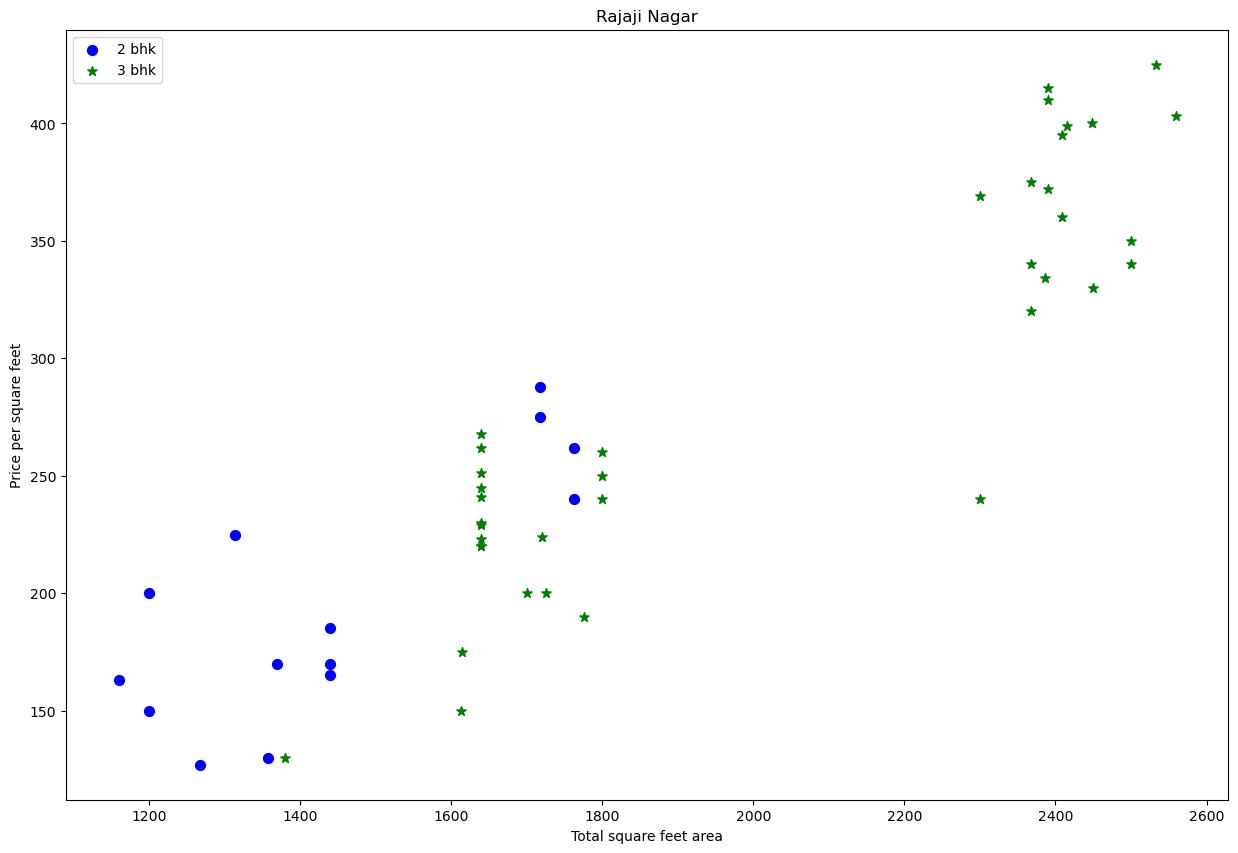

In [106]:
plot_scatter(df7,'Rajaji Nagar')

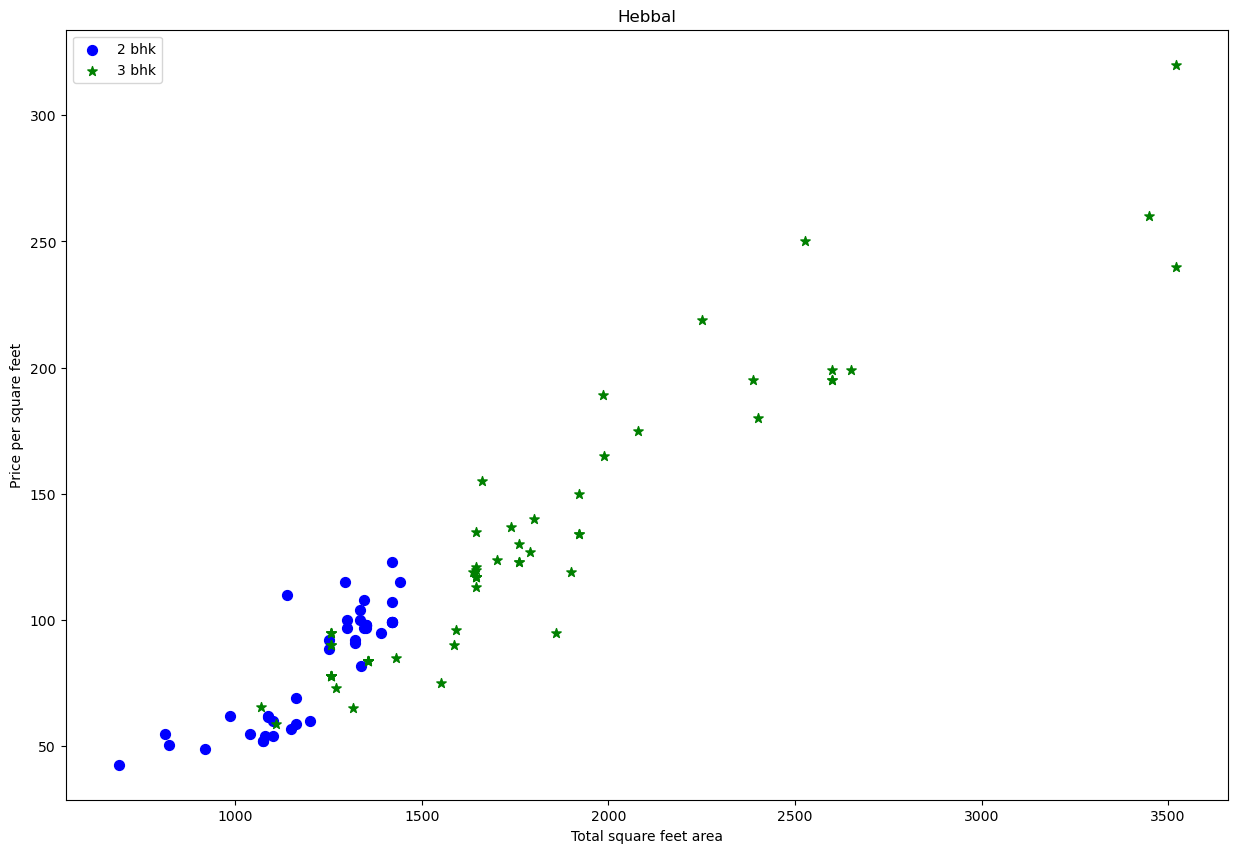

In [107]:
plot_scatter(df7,'Hebbal')

In [108]:
def remove_bhk_outliers(df):
    exclude_indices = np.array([])
    for location, location_df in df.groupby('location'):
        bhk_stats={}
        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk]={
                'mean':np.mean(bhk_df.price_per_sqft),
                'std':np.std(bhk_df.price_per_sqft),
                'count':bhk_df.shape[0]
            }
        for bhk, bhk_df in location_df.groupby('bhk'):
            stats = bhk_stats.get(bhk-1)
            if stats and stats['count']>5:
                exclude_indices=np.append(exclude_indices, bhk_df[bhk_df.price_per_sqft<(stats['mean'])].index.values)
    return df.drop(exclude_indices, axis='index')
    

In [109]:
df8 =remove_bhk_outliers(df7)
df8.shape

(7329, 7)

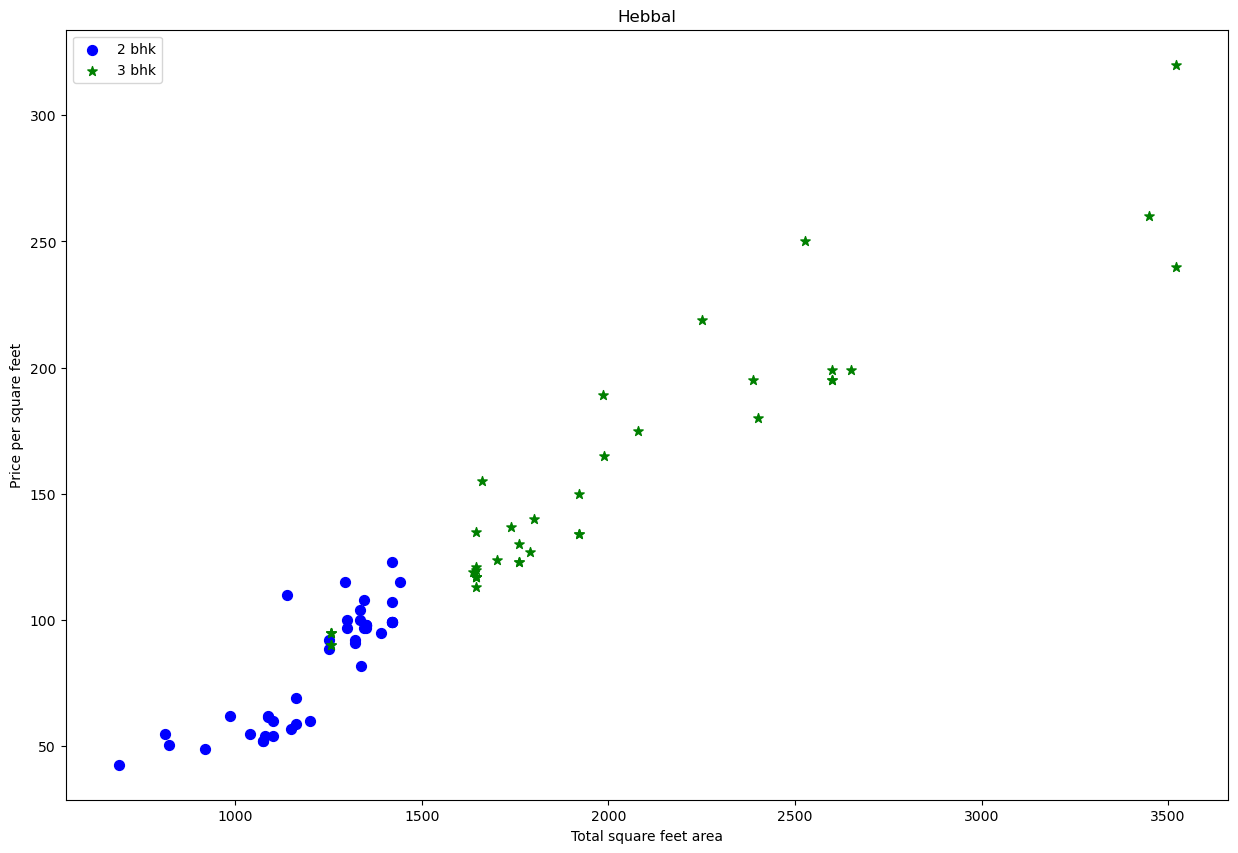

In [110]:
plot_scatter(df8, 'Hebbal')

Text(0, 0.5, 'Count')

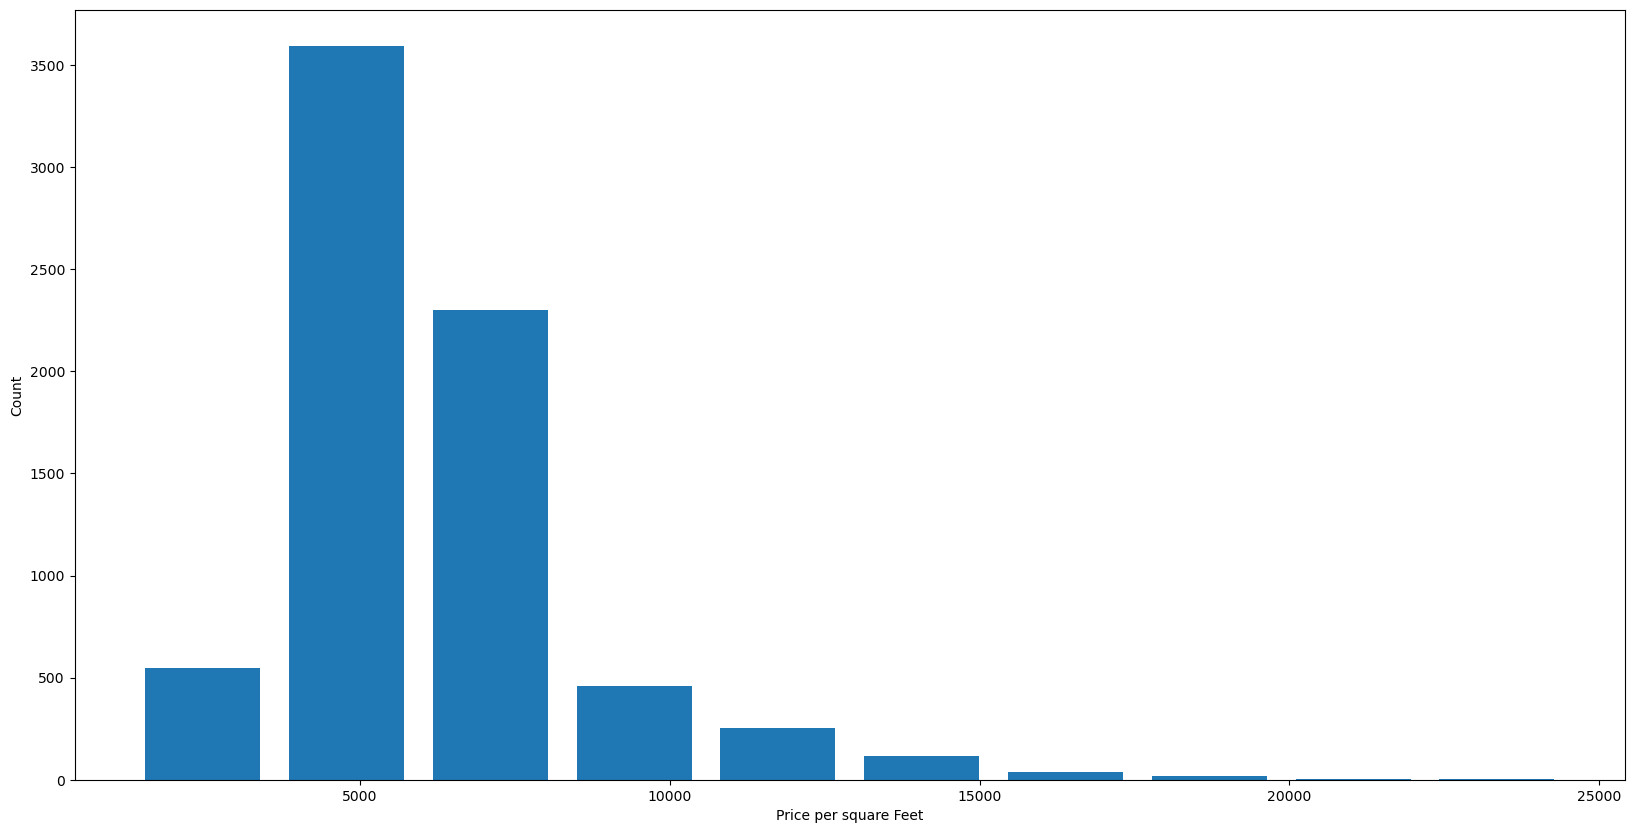

In [111]:
plt.hist(df8.price_per_sqft, rwidth=0.8)
plt.xlabel('Price per square Feet')
plt.ylabel('Count')

In [112]:
df8.columns

Index(['location', 'size', 'total_sqft', 'bath', 'price', 'bhk',
       'price_per_sqft'],
      dtype='object')

In [113]:
df8.bath.unique()

array([ 4.,  3.,  2.,  5.,  8.,  1.,  6.,  7.,  9., 12., 16., 13.])

In [114]:
df8[df8.bath>10]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
5277,Neeladri Nagar,10 BHK,4000.0,12.0,160.0,10,4000.000000
8486,other,10 BHK,12000.0,12.0,525.0,10,4375.000000
8575,other,16 BHK,10000.0,16.0,550.0,16,5500.000000
9308,other,11 BHK,6000.0,12.0,150.0,11,2500.000000
9639,other,13 BHK,5425.0,13.0,275.0,13,5069.124424


Text(0, 0.5, 'Count')

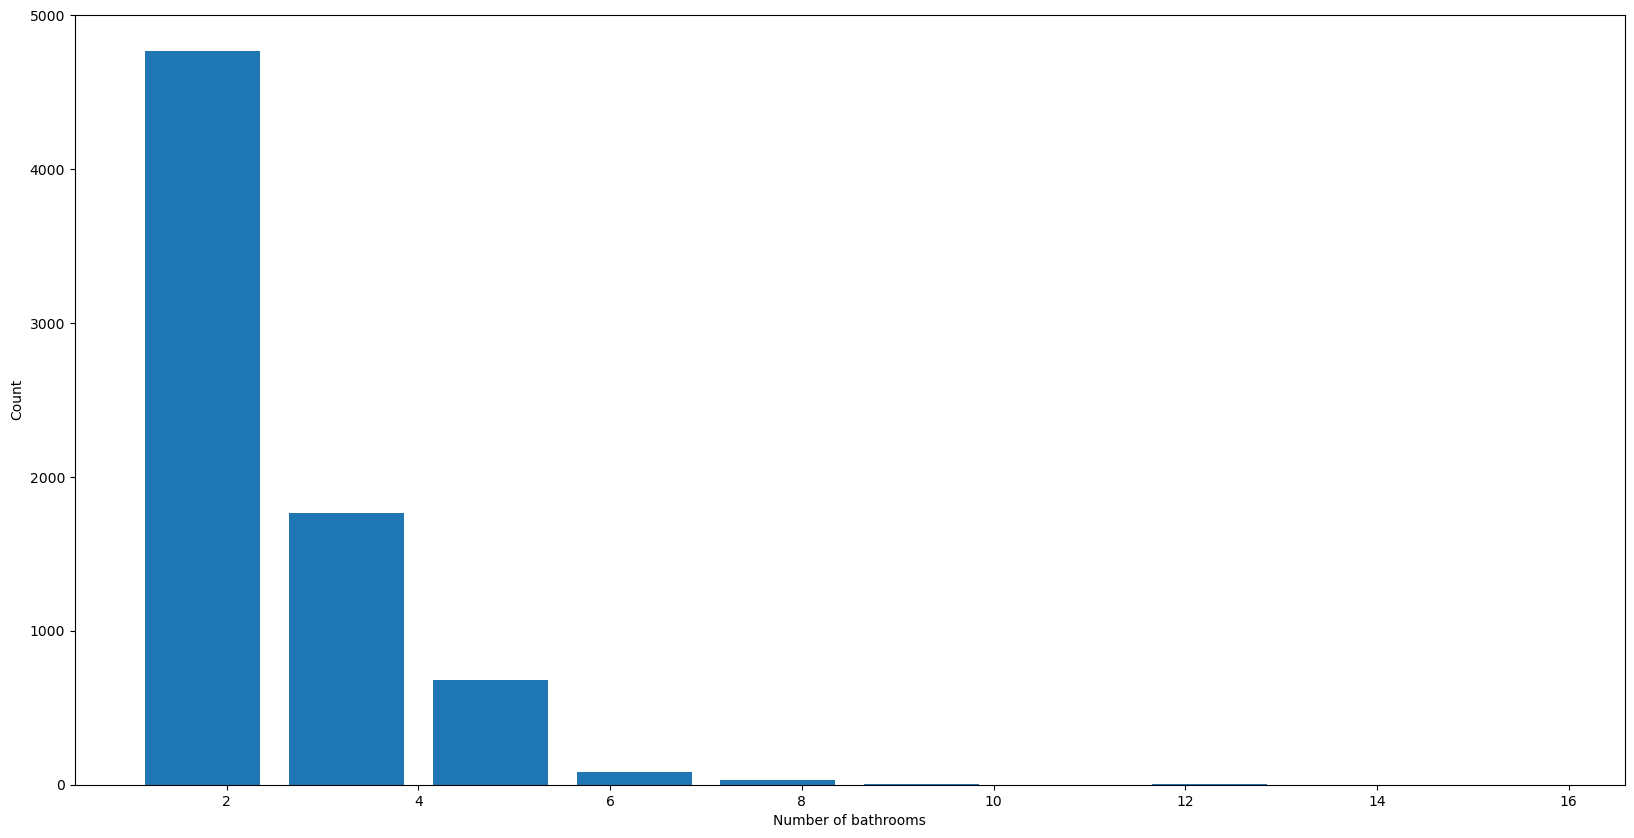

In [115]:
plt.hist(df8.bath, rwidth=0.8)
plt.xlabel("Number of bathrooms")
plt.ylabel("Count")

In [116]:
df8[df8.bath>df8.bhk+2]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
1626,Chikkabanavar,4 Bedroom,2460.0,7.0,80.0,4,3252.032520
5238,Nagasandra,4 Bedroom,7000.0,8.0,450.0,4,6428.571429
6711,Thanisandra,3 BHK,1806.0,6.0,116.0,3,6423.034330
8411,other,6 BHK,11338.0,9.0,1000.0,6,8819.897689


In [117]:
df9 =df8[df8.bath<df8.bhk+2]
df9.shape

(7251, 7)

In [118]:
df10= df9.drop(['size','price_per_sqft'], axis='columns')
df10.head()

,location,total_sqft,bath,price,bhk
0,1st Block Jayanagar,2850.0,4.0,428.0,4
1,1st Block Jayanagar,1630.0,3.0,194.0,3
2,1st Block Jayanagar,1875.0,2.0,235.0,3
3,1st Block Jayanagar,1200.0,2.0,130.0,3
4,1st Block Jayanagar,1235.0,2.0,148.0,2


In [119]:
dummies = pd.get_dummies(df10.location)
dummies.head()

,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,9th Phase JP Nagar,...,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,other
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [120]:
df11 = pd.concat([df10, dummies.drop('other', axis='columns')], axis='columns')
df11

,location,total_sqft,bath,price,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,1st Block Jayanagar,2850.0,4.0,428.0,4,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1st Block Jayanagar,1630.0,3.0,194.0,3,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1st Block Jayanagar,1875.0,2.0,235.0,3,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1st Block Jayanagar,1200.0,2.0,130.0,3,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1st Block Jayanagar,1235.0,2.0,148.0,2,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10232,other,1200.0,2.0,70.0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10233,other,1800.0,1.0,200.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10236,other,1353.0,2.0,110.0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10237,other,812.0,1.0,26.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [121]:
df11.shape

(7251, 246)

In [122]:
df12=df11.drop('location', axis='columns')

In [123]:
df12.shape

(7251, 245)

In [124]:
X=df12.drop("price", axis='columns')
y =df12.price

In [125]:
from sklearn.model_selection import train_test_split
X_train, X_test,y_train,y_test = train_test_split(X,y, test_size=0.2,random_state=10)

In [126]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr.score(X_test,y_test)

0.8452277697874279

In [127]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score

cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
cross_val_score(LinearRegression(), X,y,cv=cv)

array([0.82430186, 0.77166234, 0.85089567, 0.80837764, 0.83653286])

In [128]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor

In [129]:
def find_best_model_usingGridSearchCV(X,y):
    algos ={
        'lr': {
            'model':LinearRegression(),
            'params':{
                'fit_intercept':[True, False]
                }
            },
        'lasso':{
            'model':Lasso(),
            'params':{
                'alpha':[1,2],
                'selection':['random','cyclic']
            }
            },
            'DT':{
                'model':DecisionTreeRegressor(),
                'params':{
                    'criterion':['squared_error','friedman_mse'],
                    'splitter':['best','random']
                }
            }
    }
    score =[]
    cv = ShuffleSplit(n_splits=5,test_size=0.2, random_state=0)
    for algo, config in algos.items():
        gs = GridSearchCV(config['model'],config['params'],cv=cv,return_train_score=False)
        gs.fit(X,y)
        score.append({
            'model':algo,
            'best_score':gs.best_score_,
            'best_params': gs.best_params_
        })
    return pd.DataFrame(score,columns=['model','best_score','best_params'])
find_best_model_usingGridSearchCV(X,y)

,model,best_score,best_params
0,lr,0.819001,{'fit_intercept': False}
1,lasso,0.687429,"{'alpha': 1, 'selection': 'cyclic'}"
2,DT,0.726076,"{'criterion': 'friedman_mse', 'splitter': 'best'}"


Linear regression works well with fit_intercept= Falses

In [130]:
def predict_price(location, sqft,bath, bhk):
    loc_index = np.where(X.columns ==location)[0][0]
    
    x=np.zeros(len(X.columns))
    x[0]=sqft
    x[1]=bath
    x[2]=bhk
    if loc_index>=0:
        x[loc_index]=1
    return lr.predict([x])[0]

In [131]:
predict_price('1st Phase JP Nagar', 1000, 2,2)

C:\Users\pc\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


83.49904677167738

In [64]:
predict_price('1st Phase JP Nagar', 500, 1,1)

C:\Users\pc\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


40.48521262919632

In [65]:
predict_price('Indira Nagar', 1000, 2,2)

C:\Users\pc\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


181.27815484007036

In [75]:
import pickle

with open('bangalore_homeprice.pkl','wb') as f:
    pickle.dump(lr,f)


 Our model is ready as a pkl file in the same location

- We also need the columns information so we'll import it into a json file

In [83]:
import json
cols = {
    'data_columns': [col.lower() for col in X.columns]
}

with open('banglore_homeprice_columns.json', 'w') as f:
    f.write(json.dumps(cols))

In [84]:
col = pd.read_json('banglore_homeprice_columns.json')

In [85]:
col

,data_columns
0,total_sqft
1,bath
2,bhk
3,1st block jayanagar
4,1st phase jp nagar
...,...
239,yelachenahalli
240,yelahanka
241,yelahanka new town
242,yelenahalli


1. In Data Science, 
A/B testing is often used during Model Deployment.
- Version A (Control): Your current Linear Regression model.
- Version B (Variant): A new model (e.g., a Random Forest or an XGBoost model).

You "test" them by routing a small percentage of real-world traffic to Version B. If Version B produces more accurate predictions or better business results (like higher user engagement with the price tool), you swap A for B.

The A/B Testing Workflow:
- Hypothesis: "Using a non-linear model will reduce the Mean Absolute Error (MAE) by 5%."
- Randomization: Randomly split incoming prediction requests between Model A and Model B.
- Measurement: Track the error rates of both models over a set period.
- Action: If B is statistically significantly better, promote it to the primary model.

2. Applying it to your Notebook
Since you are in the training phase, you can simulate the "testing" of different strategies before they ever reach a user. 
 A. Test Different Feature Engineering Strategies
 In your notebook, you handled outliers in total_sqft and bath. You could "A/B test" your preprocessing:
 Approach A: Use the current outlier removal (standard deviation).
 Approach B: Use a different method (like Interquartile Range - IQR) or keep the outliers but use a robust scaler.
 Evaluation: Compare the cross-validation scores for both.
 
 B. Model Comparison (The most common use):
 GridSearchCV is essentially an automated "A/B/C test" for hyperparameters! 
 To make it a true "Challenge," 
 try comparing your Linear Regression against a more complex model:

In [132]:
from sklearn.ensemble import RandomForestRegressor

# Version B: Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=10)
rf.fit(X_train, y_train)
print(f"RF Score: {rf.score(X_test, y_test)}")

RF Score: 0.7959082339037211


In [134]:
from sklearn.model_selection import cross_val_score

score_a = cross_val_score(lr, X, y, cv = 5)
score_b = cross_val_score(rf, X,y, cv=5)

print(f'avg score of linear model -> {np.mean(score_a):.2f}')
print(f'avg score of random forest model -> { np.mean(score_b):.2f}')

if np.mean(score_a) > np.mean(score_b):
    print('Action: Deploy model B')
else:
    print('Action: Deploy Model A')


avg score of linear model -> -1566796829761219.50
avg score of random forest model -> 0.60
Action: Deploy Model A


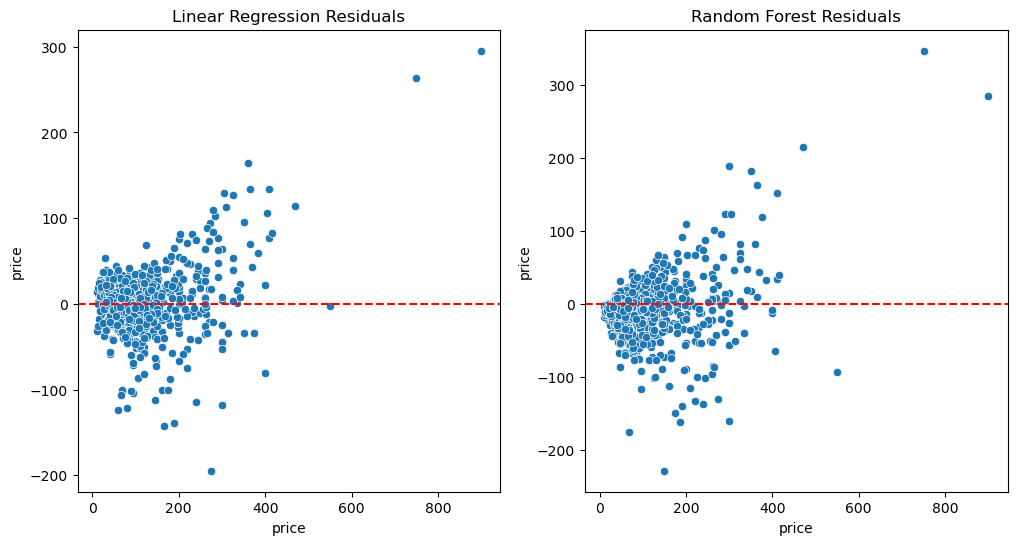

In [135]:
import seaborn as sns

# Get predictions
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

plt.figure(figsize=(12, 6))

# Plotting Residuals
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=(y_test - y_pred_lr))
plt.title('Linear Regression Residuals')
plt.axhline(y=0, color='r', linestyle='--')

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=(y_test - y_pred_rf))
plt.title('Random Forest Residuals')
plt.axhline(y=0, color='r', linestyle='--')

plt.show()

he points are scattered randomly around the red line, the model is good. If there is a pattern (like a cone shape), your model is struggling with high-value properties.

The reason your Random Forest scored lower might be because the default parameters aren't right for Bangalore's housing density. Let's add it to your find_best_model_usingGridSearchCV function.

In [ ]:
# Add this inside your algos dictionary in the find_best_model function
''''random_forest': {
    'model': RandomForestRegressor(),
    'params': {
        'n_estimators': [50, 100],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    }
}'''

In [136]:
def find_best_model_usingGridSearchCV(X,y):
    algos ={
        'lr': {
            'model':LinearRegression(),
            'params':{
                'fit_intercept':[True, False]
                }
            },
        'lasso':{
            'model':Lasso(),
            'params':{
                'alpha':[1,2],
                'selection':['random','cyclic']
            }
            },
            'DT':{
                'model':DecisionTreeRegressor(),
                'params':{
                    'criterion':['squared_error','friedman_mse'],
                    'splitter':['best','random']
                }
            },
        'random_forest': {
            'model': RandomForestRegressor(),
            'params': {
                'n_estimators': [50, 100],
                'max_depth': [10, 20, None],
                'min_samples_split': [2, 5]
                }
            }
    }
    score =[]
    cv = ShuffleSplit(n_splits=5,test_size=0.2, random_state=0)
    for algo, config in algos.items():
        gs = GridSearchCV(config['model'],config['params'],cv=cv,return_train_score=False)
        gs.fit(X,y)
        score.append({
            'model':algo,
            'best_score':gs.best_score_,
            'best_params': gs.best_params_
        })
    return pd.DataFrame(score,columns=['model','best_score','best_params'])
find_best_model_usingGridSearchCV(X,y)

,model,best_score,best_params
0,lr,0.819001,{'fit_intercept': False}
1,lasso,0.687429,"{'alpha': 2, 'selection': 'random'}"
2,DT,0.716595,"{'criterion': 'squared_error', 'splitter': 'be..."
3,random_forest,0.791410,"{'max_depth': 20, 'min_samples_split': 5, 'n_e..."


consider Feature Importance. Random Forest can tell you exactly which factors (Location vs. Square Feet vs. Bathrooms) drive the price the most.

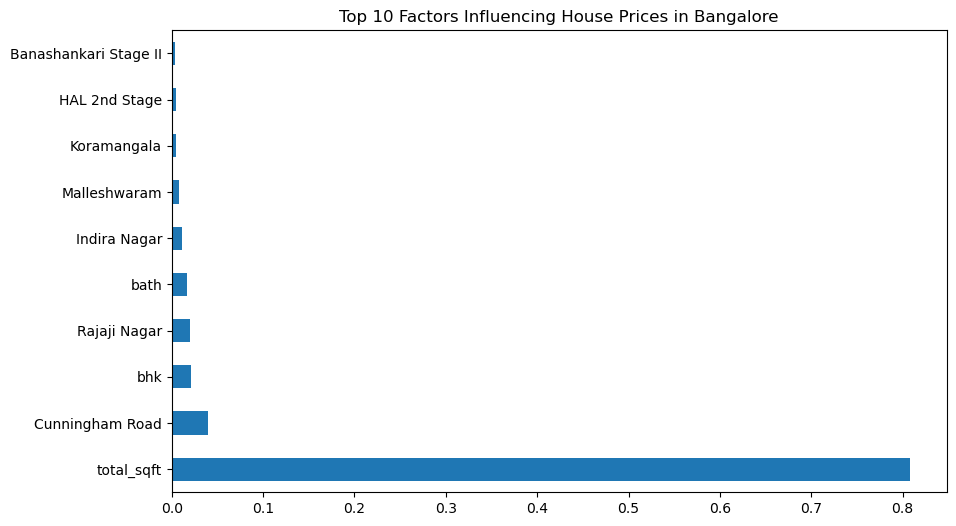

In [137]:
importances = rf.feature_importances_
feature_names = X.columns
rf_importances = pd.Series(importances, index=feature_names)

# Look at the top 10 most influential factors
plt.figure(figsize=(10,6))
rf_importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Factors Influencing House Prices in Bangalore")
plt.show()

In [139]:
# building a pipeline to make code cleaner 

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# define which columns need which treatment
numeric_features = ['total_sqft', 'bath', 'bhk']
cat_features = ['location']

# create the preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])
# Create the full pipeline
clf = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LinearRegression())
    ])

# Fit the pipeline (we have to use df10 for this)
X_pipe = df10.drop('price', axis=1)
y_pipe = df10['price']


X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_pipe, y_pipe, test_size=0.2)
clf.fit(X_train_p,y_train_p )

print(f"Pipeline score : {clf.score(X_test_p,y_test_p)}")

Pipeline score : 0.8711589314763448


In [140]:
# Calculate the mean price per location
location_mapping = df10.groupby('location')['price'].mean().to_dict()

# Map the mean price back to the dataframe
df10['location_refined'] = df10['location'].map(location_mapping)

# Now your model has a numerical "Location Score" instead of hundreds of dummy columns
X_refined = df10[['total_sqft', 'bath', 'bhk', 'location_refined']]
y_refined = df10['price']

lr_refined = LinearRegression()
lr_refined.fit(X_refined, y_refined)
print(f"Refined Location Model Score: {lr_refined.score(X_refined, y_refined)}")

Refined Location Model Score: 0.8307773533989333


In [141]:
rf_tuned = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5)
rf_tuned.fit(X_train, y_train)
print(f"Tuned RF Score: {rf_tuned.score(X_test, y_test)}")

Tuned RF Score: 0.7729015448508407


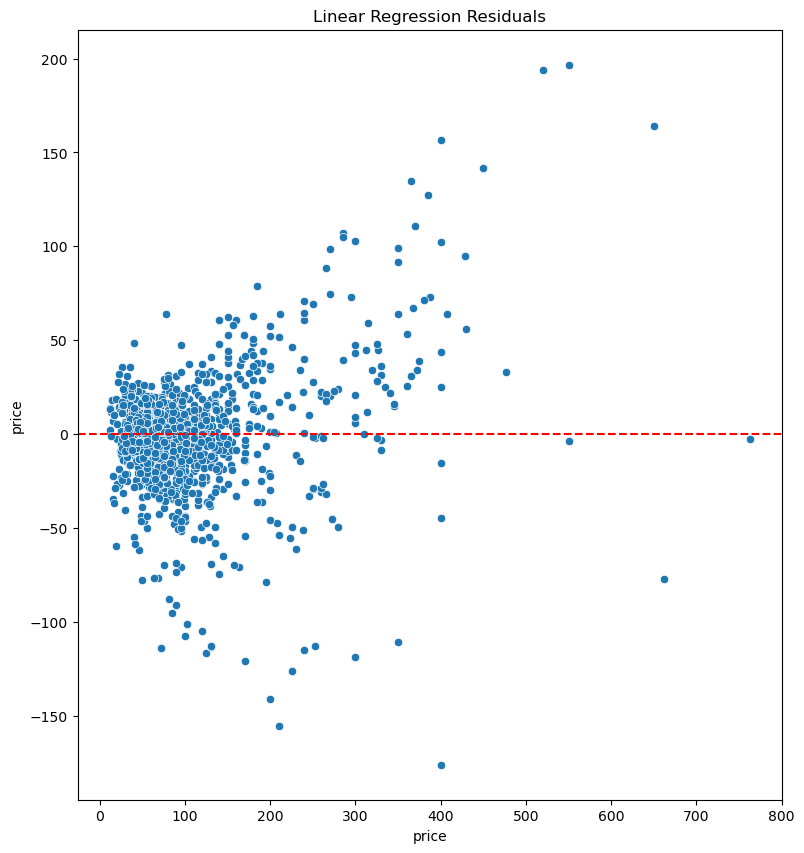

In [142]:
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_p, y=(y_test_p - clf.predict(X_test_p)))
plt.title('Linear Regression Residuals')
plt.axhline(y=0, color='r', linestyle='--')